<a href="https://colab.research.google.com/github/grkenney/WinSPIRE-HLC-Python/blob/main/Notebooks/Keys/Day_3.3_Scatterplots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scatterplots
Scatterplots are used to examine the relationship between two continuous numeric variables.

In [20]:
# import seaborn and nickname it sns
import seaborn as sns

# import pandas and nickname it pd
import pandas as pd

# import matplotlib.pyplot and nickname it plt
import matplotlib.pyplot as plt

# set up inline figures
%matplotlib inline

Next, let's load in our data set.

In [21]:
url = 'https://github.com/grkenney/WinSPIRE-HLC-Python/raw/refs/heads/main/data/qPCR_data_cleaned.csv'
df = pd.read_csv(url)
df.head()

,sample_id,treatment_group,well,timepoint,MKI67,MTOR,BAX,IRF1
0,657317,Control,1,0,1.004377,1.379025,0.799135,0.672194
1,657317,Control,2,8,0.894172,1.345400,0.956142,0.756379
2,657317,Control,3,16,0.679445,1.098444,1.209928,0.050000
3,657317,Control,4,24,0.721341,1.063588,1.586136,0.643022
4,407401,Control,5,0,1.091682,0.843497,0.354864,0.489234


Remember how we wanted to exclude that data point where `MTOR` was > 9. Let's subset our data frame again here before we get into plotting.

In [22]:
# subset df to rows where MTOR < 9
df = df.query("MTOR < 9")

Say we want to look at the relationship between **BAX** and **IRF1** within our dataset. We’ll use the **sns.scatterplot** function to plot this.

<Axes: xlabel='BAX', ylabel='IRF1'>

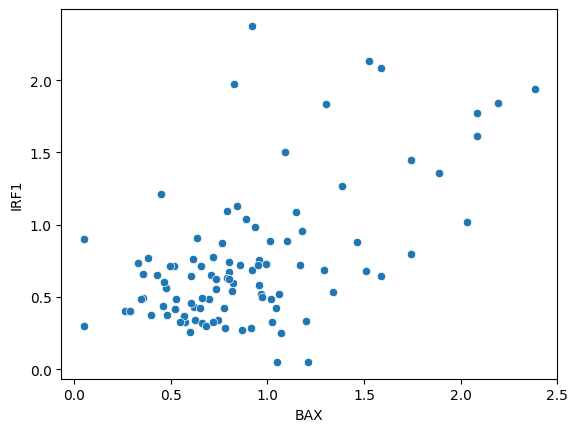

In [23]:
# plot BAX vs IRF1
sns.scatterplot(data=df, x = 'BAX', y = 'IRF1')

Similar to the previous plots we've worked with so far, we can change the color of the points with the `hue` parameter. Let's color these points by `treatment_group`.

<Axes: xlabel='BAX', ylabel='IRF1'>

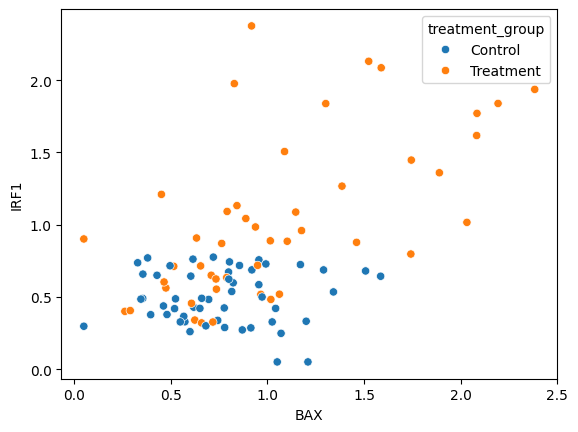

In [24]:
# plot BAX vs IRF1 and color by treatment_group
sns.scatterplot(data=df, x = 'BAX', y = 'IRF1', hue="treatment_group")

We can also use `style` parameter to style the points by a category. And we can even specify which points we want for each category using the `markers` parameter. 

There are many markers to choose from, but here are a few popular choices:
`"o"`, `"^"`, `"v"`, `"<"`, `">"`, `"s"`, `"D"`, `"d"`, `"p"`, `"h"`, `"*"`, `"."`, `"P"`

Let's try to use both here to style by `treatment_group` and use dots(`"."`) for the control samples and stars (`"*"`) for the treatment samples.

<Axes: xlabel='BAX', ylabel='IRF1'>

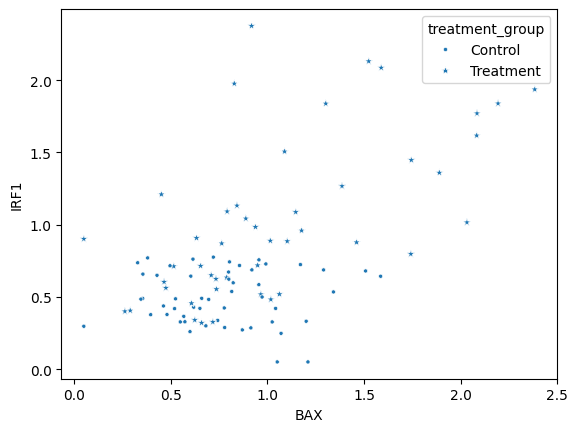

In [25]:
# plot BAX vs IRF1 and style by treatment_group
# use . for control and * for treatment
sns.scatterplot(data=df, x = 'BAX', y = 'IRF1',
                style="treatment_group",  markers=['.', '*'])

Those points are tiny! Let's make them a little bigger with the `s` parameter. Start with `s=500`.

<Axes: xlabel='BAX', ylabel='IRF1'>

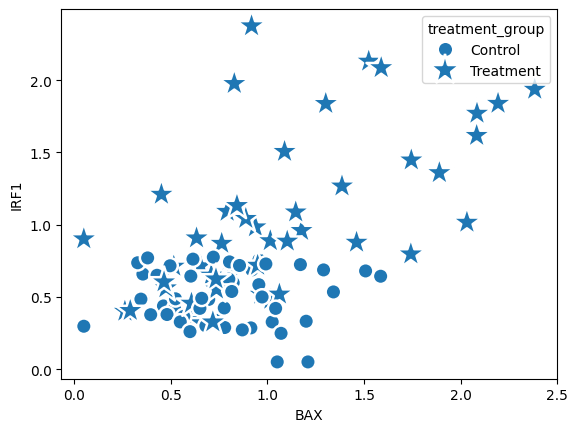

In [26]:
# plot BAX vs IRF1 and style by treatment_group
# use . for control and * for treatment
# change s to 500
sns.scatterplot(data=df, x = 'BAX', y = 'IRF1', 
                style="treatment_group",  markers=['.', '*'], s=500)

Lastly, if we wanted to visualize the trend of the points on a scatterplot, we can use the `lmplot` function to visualize both scatter and a trendline. Let's try doing this for `BAX` versus `IRF1` but also coloring by `treatment_group` to visualize the overall trends in this data.

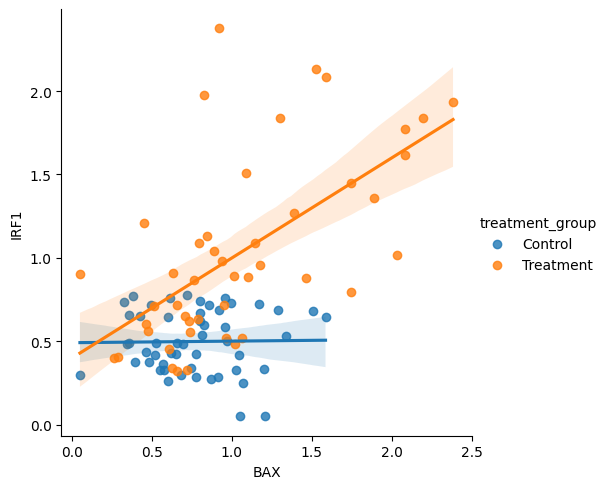

In [27]:
# plot BAX vs IRF1 with trendline and color by treatment_group
sns.lmplot(data=df, x = 'BAX', y = 'IRF1', hue="treatment_group")

The options to customize a seaborn plot are endless, but here are some last few tips to make your plot look more professional:
* `despine` removes upper and right lines around the plot area
* `xlim` and `ylim` allow you to choose a lower and upper bound for the axes scales
* `legend` allows us to edit our legend with several parameters:
    * `title` changes the title of the legend
    * `loc` changes the legend placement
    * `bbox_to_anchor` allows you specify the exact position of the legend
 
**Exercise:** based on the above descriptions of these functions, try to edit the plot below to do the following:
* Change the upper limit of the x-axis to 4
* Change the upper limit of the y-axis to 3
* Change the name of the legend to "Group"
* Move the legend to be centered below the plot

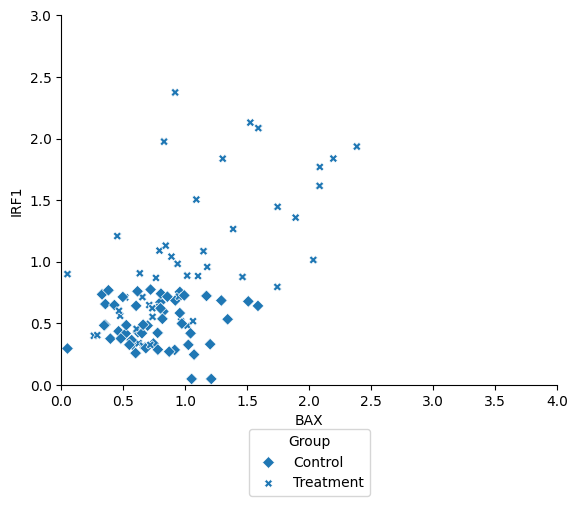

In [28]:
sns.scatterplot(data=df, x = 'BAX', y = 'IRF1', 
                style="treatment_group",  markers=['D', 'X'])
sns.despine()
plt.xlim(0, 4)
plt.ylim(0, 3)
plt.legend(title="Group", loc='upper center', bbox_to_anchor=(0.5, -0.1))

**Exercise:** For your last plotting exercise, let's try looking at a whole new data set. Palmer's penguins is a data set of information about different species of penguins from different islands.

In [29]:
# load the penguins data set
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Try to using a single scatterplot to answer the following questions:
* Is penguin body mass correlated to flipper length?
* Which species of penguins have the largest flippers and body mass?
* Are male or female Gentoo penguins larger?

Hint: You can use `hue` and `style` to categorize the points.

<Axes: xlabel='flipper_length_mm', ylabel='body_mass_g'>

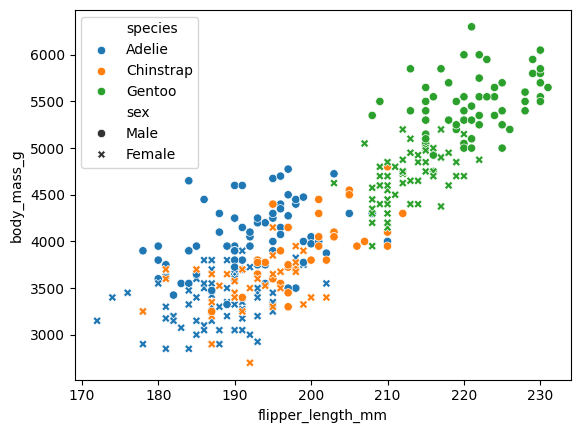

In [30]:
# scatterplot
sns.scatterplot(data = penguins, x = "flipper_length_mm", y = "body_mass_g", 
                style = "sex", hue = "species")

Copy your plot from above and try making the following customizations:
* Change the size of the points (`s` parameter in `scatterplot`)
* Change the colors to anything you want (`palette` parameter in `scatterplot`)
* "Despine" the plot (`sns.despine()`)
* Save your plot to a variable `p`
* Add a title to the plot (`p.set_title()`)
* Change the axis labels (`p.set_xlabel()` and `p.set_ylabel()`)

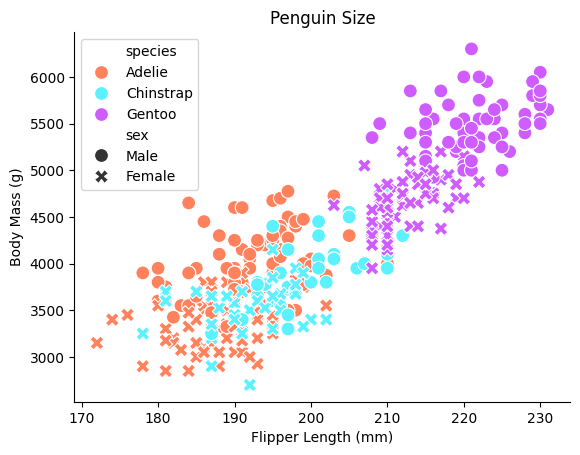

In [31]:
# copy your scatter plot from above here
p = sns.scatterplot(data = penguins, x = "flipper_length_mm", y = "body_mass_g", 
                    style = "sex", hue = "species",
                    s = 100, palette = ["#FF825C", "#5CF1FF", "#CE5CFF"])
p.set_title("Penguin Size")
p.set_xlabel("Flipper Length (mm)")
p.set_ylabel("Body Mass (g)")
sns.despine()